# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [196]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [197]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [198]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}

# ╔══════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 2а: Для каждой модели в base_models         ║
# ║  вычислите 5-fold CV с scoring='f1_macro'            ║
# ║  Сохраните mean и std в baseline_results             ║
# ╚══════════════════════════════════════════════════════╝

# YOUR CODE HERE
for name, model in base_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro')
    baseline_results[name] = (scores.mean(), scores.std())

# После заполнения — вывод результатов:
for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [199]:
from sklearn.model_selection import GridSearchCV

# Pipeline: нормировка + SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3а: Задайте сетку параметров для GridSearchCV       ║
# ║  Параметры SVM через Pipeline: 'svm__C', 'svm__gamma',       ║
# ║  'svm__kernel'                                               ║
# ║  Попробуйте: C in [0.1, 1, 10, 100],                        ║
# ║  gamma in ['scale', 0.01, 0.001], kernel in ['rbf','linear'] ║
# ╚══════════════════════════════════════════════════════════════╝

svm_param_grid = {
    # YOUR CODE HERE
    'svm__C' : [0.1, 1, 10, 100],
    'svm__gamma' : ['scale', 0.01, 0.001],
    'svm__kernel' : ['rbf', 'linear']
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3б: Создайте и запустите GridSearchCV               ║
# ║  cv=5, scoring='f1_macro', n_jobs=-1                         ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
# svm_grid_search = ...
svm_grid_search = GridSearchCV(estimator=svm_pipe, param_grid=svm_param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
# svm_grid_search.fit(...)
svm_grid_search.fit(X_train, y_train)

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")
print(f"Mean + std:", f"{svm_grid_search.cv_results_['mean_test_score'][svm_grid_search.best_index_]:.4f} ± {svm_grid_search.cv_results_['std_test_score'][svm_grid_search.best_index_]:.4f}")

Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786
Mean + std: 0.9786 ± 0.0176


In [200]:
# Анализируем результаты Grid Search

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3в: Создайте DataFrame из svm_grid_search.cv_results║
# ║  Выберите колонки: params, mean_test_score, std_test_score,  ║
# ║  rank_test_score                                             ║
# ║  Выведите топ-10 конфигураций                                ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
cv_results_df = pd.DataFrame(svm_grid_search.cv_results_
                        )[["params", "mean_test_score", "std_test_score", "rank_test_score"]]
print(cv_results_df.sort_values("rank_test_score").head(10))   

                                               params  mean_test_score  \
14  {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kerne...         0.978633   
1   {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__k...         0.976215   
5   {'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__ker...         0.976215   
3   {'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kern...         0.976215   
22  {'svm__C': 100, 'svm__gamma': 0.001, 'svm__ker...         0.976157   
16  {'svm__C': 10, 'svm__gamma': 0.001, 'svm__kern...         0.971340   
6   {'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...         0.969357   
12  {'svm__C': 10, 'svm__gamma': 'scale', 'svm__ke...         0.969350   
20  {'svm__C': 100, 'svm__gamma': 0.01, 'svm__kern...         0.966936   
8   {'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...         0.966732   

    std_test_score  rank_test_score  
14        0.017581                1  
1         0.015266                2  
5         0.015266                2  
3         0.015266               

## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [201]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4а: Задайте пространство параметров для             ║
# ║  RandomizedSearchCV на RandomForestClassifier                ║
# ║  Попробуйте:                                                 ║
# ║    n_estimators: randint(50, 500)                            ║
# ║    max_depth: randint(2, 20) или None                        ║
# ║    min_samples_split: randint(2, 20)                         ║
# ║    max_features: ['sqrt', 'log2', 0.5]                       ║
# ╚══════════════════════════════════════════════════════════════╝

rf_param_dist = {
    # YOUR CODE HERE
    'n_estimators' : randint(50, 500),
    'max_depth' : [None] + list(randint(2, 20).rvs(size=10).astype(int)),
    'min_samples_split' : randint(2, 20),
    'max_features' : ['sqrt', 'log2', 0.5]
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4б: Создайте RandomizedSearchCV                     ║
# ║  n_iter=50, cv=5, scoring='f1_macro',                        ║
# ║  random_state=42, n_jobs=-1                                  ║
# ║  Обучите на X_train, y_train                                 ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_random_search = RandomizedSearchCV(estimator=base_models['RandomForest'], 
                                      param_distributions=rf_param_dist, n_iter=50, cv=5, scoring='f1_macro',
                                      random_state=42, n_jobs=-1)
rf_random_search.fit(X_train, y_train)

print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")
print(f"Mean + std:", f"{rf_random_search.cv_results_['mean_test_score'][rf_random_search.best_index_]:.4f} ± {rf_random_search.cv_results_['std_test_score'][rf_random_search.best_index_]:.4f}")

Лучшие параметры RF: {'max_depth': np.int64(12), 'max_features': 0.5, 'min_samples_split': 3, 'n_estimators': 393}
Лучший CV F1: 0.9576
Mean + std: 0.9576 ± 0.0193


## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [202]:
from sklearn.metrics import classification_report

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 5: Оцените лучшие модели (svm_grid_search и         ║
# ║  rf_random_search) на тестовой выборке X_test, y_test        ║
# ║                                                              ║
# ║  Для каждой модели выведите classification_report            ║
# ║  Сравните с baseline моделями из шага 2                      ║
# ║                                                              ║
# ║  ВАЖНО: тест используем ТОЛЬКО ЗДЕСЬ, один раз!             ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
print("Baseline SVM:")
base_models.get('SVM').fit(X_train, y_train) 
y_pred_baseline_svm = base_models.get('SVM').predict(X_test)
print(classification_report(y_test, y_pred_baseline_svm))
print("F1 Baseline SVM:", f"{f1_score(y_test, y_pred_baseline_svm, average='macro'):.4f}")

print("\nBest SVM from Grid Search:")
best_svm = svm_grid_search.best_estimator_
y_pred_best_svm = best_svm.predict(X_test)
print(classification_report(y_test, y_pred_best_svm))
print("F1 Best SVM:", f"{f1_score(y_test, y_pred_best_svm, average='macro'):.4f}")

print("\nBaseline Random Forest:")
base_models.get('RandomForest').fit(X_train, y_train)
y_pred_baseline_rf = base_models.get('RandomForest').predict(X_test)
print(classification_report(y_test, y_pred_baseline_rf))
print("F1 Baseline RF:", f"{f1_score(y_test, y_pred_baseline_rf, average='macro'):.4f}")

print("\nBest Random Forest from Random Search:")
best_rf = rf_random_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
print(classification_report(y_test, y_pred_best_rf))
print("F1 Best RF:", f"{f1_score(y_test, y_pred_best_rf, average='macro'):.4f}")


# Заполните таблицу:
# | Модель                | CV F1 (mean±std) | Test F1 |
# |-----------------------|------------------|---------|
# | SVM baseline          |  0.9694 ± 0.0193 | 0.9812  |
# | SVM Grid Search       |  0.9786 ± 0.0176 | 0.9812  |
# | RF baseline           |  0.9504 ± 0.0255 | 0.9526  |
# | RF Random Search      |  0.9576 ± 0.0193 | 0.9526  |

Baseline SVM:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

F1 Baseline SVM: 0.9812

Best SVM from Grid Search:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

F1 Best SVM: 0.9812

Baseline Random Forest:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg     

## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

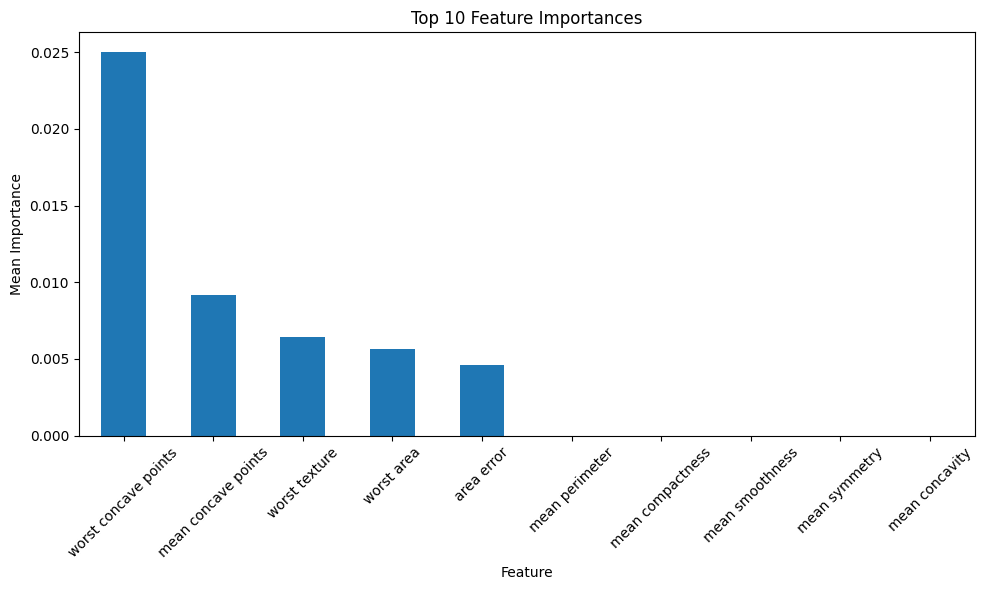

In [203]:
from sklearn.inspection import permutation_importance

# Используем лучший RF из Random Search
best_rf = rf_random_search.best_estimator_

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6а: Вычислите Permutation Importance                ║
# ║  для best_rf на X_test, y_test                               ║
# ║  n_repeats=10, random_state=42, scoring='f1_macro'           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
# pi_result = permutation_importance(...)
pi_result = permutation_importance(best_rf, X_test, y_test, n_repeats=10, random_state=42, scoring='f1_macro')

# Построим bar plot топ-10 признаков
# YOUR CODE HERE
feature_importances = pd.Series(pi_result.importances_mean, index=feature_names)
top_features = feature_importances.sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
top_features.plot(kind='bar')
plt.title('Top 10 Feature Importances')
plt.ylabel('Mean Importance')
plt.xlabel('Feature')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [204]:
# Встроенная важность RF (для сравнения)

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6б: Сравните Permutation Importance                 ║
# ║  с встроенной feature_importances_ RandomForest              ║
# ║  Совпадает ли порядок топ-5 признаков?                       ║
# ║  Если нет — как вы это объясняете?                           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_feature_importances = pd.Series(best_rf.feature_importances_, index=feature_names)
rf_top_features = rf_feature_importances.sort_values(ascending=False).head(10)
print("Top 10 features by Permutation Importance:")
print(top_features)
print("\nTop 10 features by RF built-in importance:")
print(rf_top_features)

# Вопрос для размышления:
# Некоторые признаки имеют высокий PI, но низкую встроенную важность,
# или наоборот. Что это может означать? Встроенная важность RF оценивает вклад признака в построение дерева, 
# а PI оценивает влияние на итоговую метрику. Если признак важен для построения дерева, но не влияет на F1, 
# он может быть полезен для других метрик или в других частях пространства признаков. 
# И наоборот, признак с высоким PI, но низкой встроенной важностью может быть полезен в комбинации с другими признаками, 
# но не выделяться сам по себе.

Top 10 features by Permutation Importance:
worst concave points    0.025034
mean concave points     0.009154
worst texture           0.006422
worst area              0.005680
area error              0.004593
mean perimeter          0.000000
mean compactness        0.000000
mean smoothness         0.000000
mean symmetry           0.000000
mean concavity          0.000000
dtype: float64

Top 10 features by RF built-in importance:
worst perimeter         0.218391
worst concave points    0.185255
worst area              0.146500
worst radius            0.139760
mean concave points     0.117111
worst texture           0.021991
mean concavity          0.019909
mean texture            0.017487
mean perimeter          0.013442
area error              0.013117
dtype: float64


## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

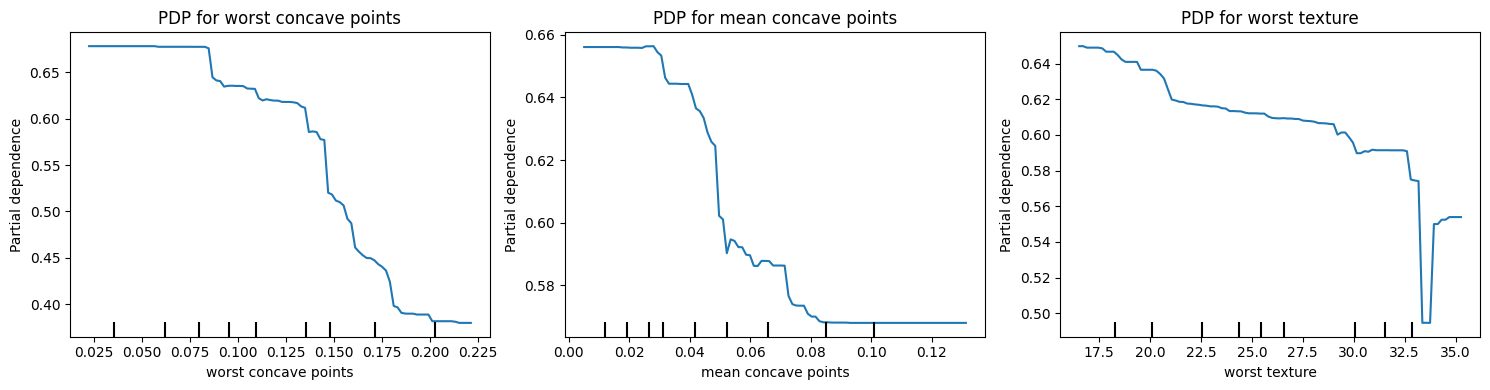

In [205]:
from sklearn.inspection import PartialDependenceDisplay

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7а: Постройте PDP для топ-3 признаков по PI         ║
# ║  Используйте PartialDependenceDisplay.from_estimator         ║
# ║  kind='average' для PDP                                      ║
# ╚══════════════════════════════════════════════════════════════╝

# Определите индексы топ-3 признаков по PI
# YOUR CODE HERE
top3_idx = feature_importances.sort_values(ascending=False).head(3).index

# Постройте PDP
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
# YOUR CODE HERE
for i, feature in enumerate(top3_idx):
    PartialDependenceDisplay.from_estimator(best_rf, X_test, [feature], kind='average', ax=ax[i])
    ax[i].set_title(f'PDP for {feature}')
plt.tight_layout()
plt.show()

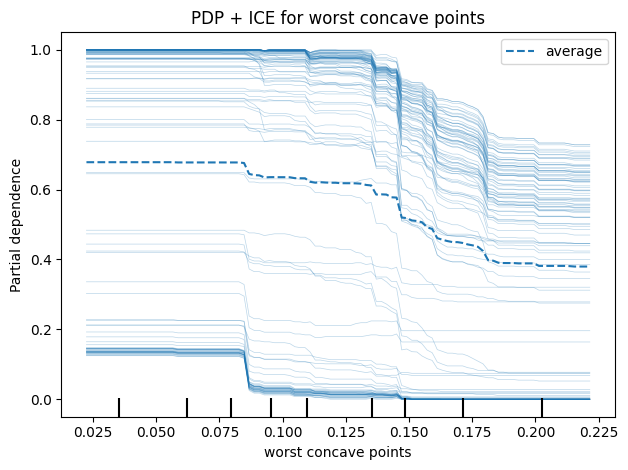

In [206]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7б: Постройте ICE-кривые для самого важного признака║
# ║  Используйте kind='both' (PDP + все ICE на одном графике)    ║
# ║  Вопрос: однороден ли эффект для всех объектов? нет          ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
most_important_feature = top3_idx[0]
PartialDependenceDisplay.from_estimator(best_rf, X_test, [most_important_feature], kind='both')
plt.title(f'PDP + ICE for {most_important_feature}')
plt.tight_layout()
plt.show()

## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [207]:
# Установка SHAP (если не установлен)
#!pip install shap

import shap

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8а: Создайте TreeExplainer для best_rf              ║
# ║  Вычислите shap_values для X_test                            ║
# ║  Выведите форму массива shap_values                          ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
# explainer = ...
explainer = shap.TreeExplainer(best_rf)
# shap_values = ...
shap_values = explainer(X_test)
print("Shape of SHAP values:", shap_values.shape)

Shape of SHAP values: (114, 30, 2)


X_test shape: (114, 30)
SHAP values[1] shape: (30, 2)


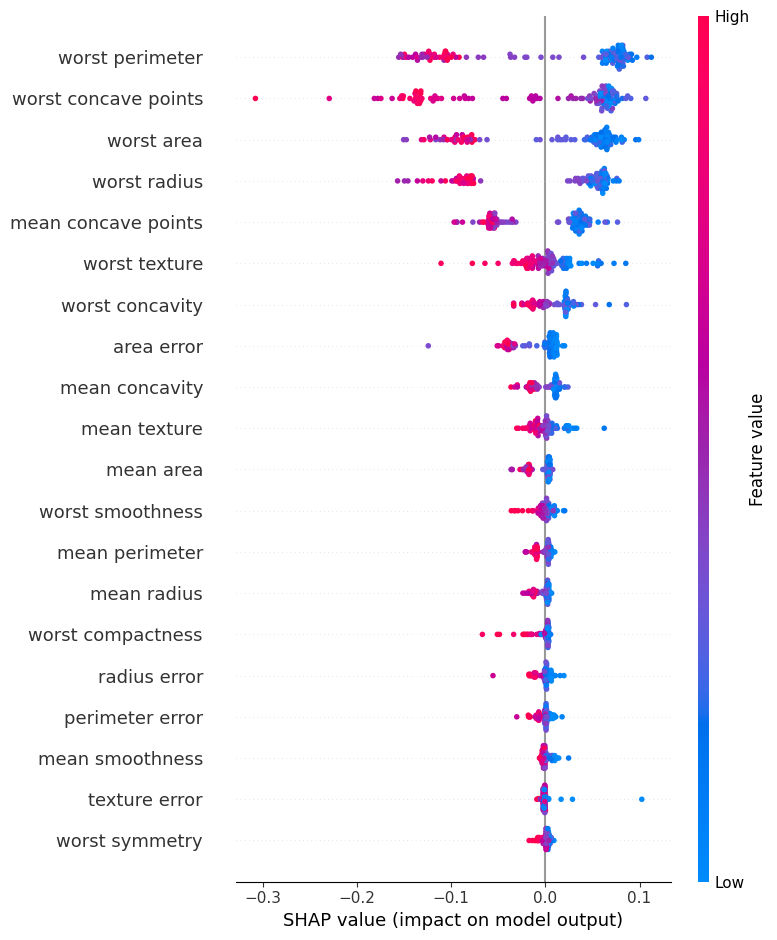

In [208]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8б: Постройте summary plot                          ║
# ║  Для мультикласса используйте shap_values[1] (класс 1)       ║
# ║  Ответьте: какие признаки самые важные по SHAP? Сверху вниз  ║
# ║  Совпадает ли с PI из шага 6? Есть, но с перестановками      ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
print(f"X_test shape: {X_test.shape}")
print(f"SHAP values[1] shape: {shap_values[1].shape}")
shap.summary_plot(shap_values[:, :, 1], X_test, feature_names=feature_names)

Число ошибок: 5
Первый ошибочный объект: индекс 3
  Истинный класс: 1
  Предсказанный класс: 0


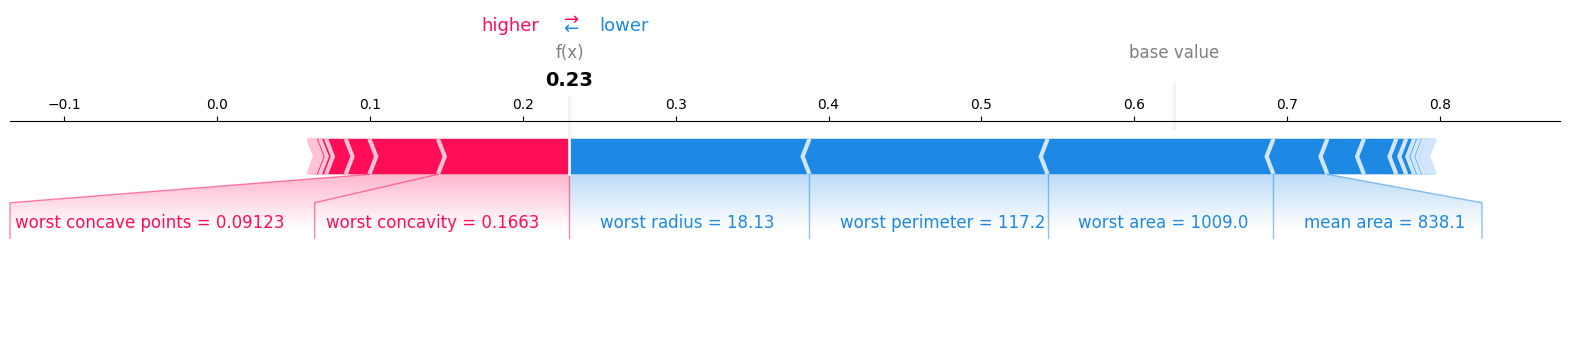

In [209]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8в: Найдите объект, на котором модель ошиблась      ║
# ║  (y_pred != y_test). Постройте для него force_plot           ║
# ║  Какие признаки «виноваты» в ошибке? Те, что отмечены синим (worst radius, worst perimeter, worst area)                        ║
# ╚══════════════════════════════════════════════════════════════╝

y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

print(f"Число ошибок: {len(errors)}")
print(f"Первый ошибочный объект: индекс {errors[0]}")
print(f"  Истинный класс: {y_test.iloc[errors[0]]}")
print(f"  Предсказанный класс: {y_pred_test[errors[0]]}")

# YOUR CODE HERE
# shap.force_plot(...)
shap.initjs()
error_index = errors[0]
shap.plots.force(shap_values[error_index, :, 1], matplotlib=True)

## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [210]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())

Добавлены признаки: leaky_feature, random_feature
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
184        15.28         22.41           98.92      710.6          0.09057   
300        19.53         18.90          129.50     1217.0          0.11500   
509        15.46         23.95          103.80      731.3          0.11830   
230        17.05         19.08          113.40      895.0          0.11410   
474        10.88         15.62           70.41      358.9          0.10070   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
184            0.1052         0.05375              0.03263         0.1727   
300            0.1642         0.21970              0.10620         0.1792   
509            0.1870         0.20300              0.08520         0.1807   
230            0.1572         0.19100              0.10900         0.2131   
474            0.1069         0.05115              0.01571         0.1861   

     mean fractal 

Permutation Importance: leaky_feature (0.2633) | mean concave points (0.0047) | worst concave points (0.0038) | mean radius (0.0000) | mean area (0.0000) | mean smoothness (0.0000) | mean perimeter (0.0000) | mean texture (0.0000) | mean symmetry (0.0000) | mean fractal dimension (0.0000)


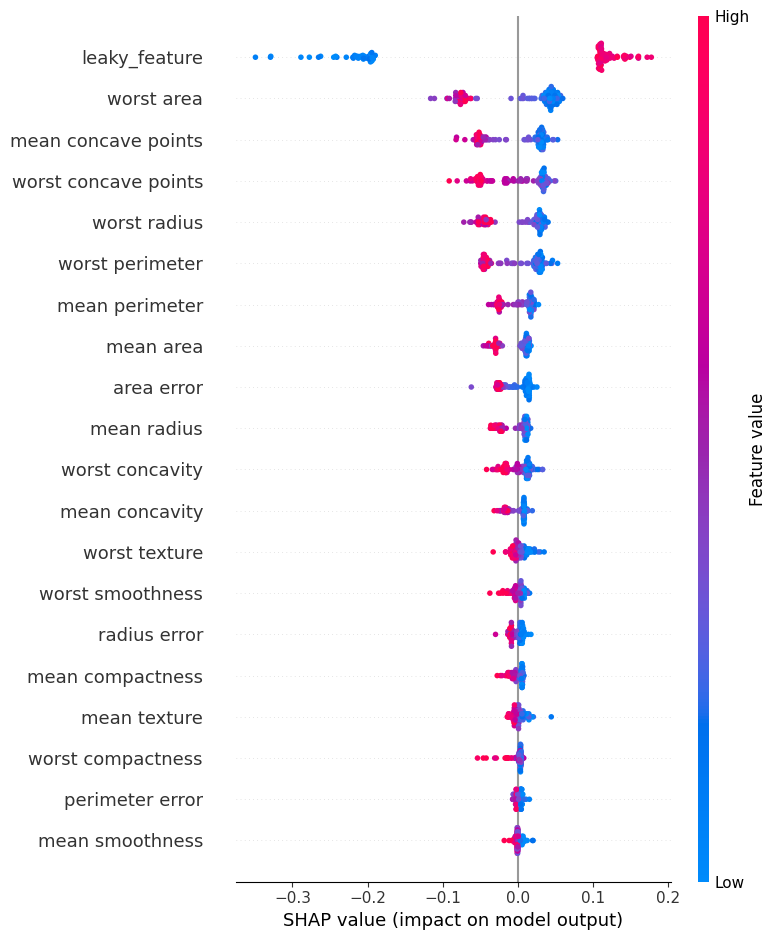

In [211]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 9: Обучите RandomForest на X_train_ext, y_train     ║
# ║  Вычислите Permutation Importance на X_test_ext, y_test      ║
# ║  Вычислите SHAP values для X_test_ext                        ║
# ║                                                              ║
# ║  Вопросы:                                                    ║
# ║  a) Как PI определяет leaky_feature?  Если при случайном перемешивании значений признака метрика на тесте сильно падает                       ║
# ║     Почему метрика на тесте выросла? Потому модель перестала предсказывать и начала просто считывать ответ из признака-утечки, который имеет высокую корреляцию с целевой переменной                        ║
# ║  б) Как SHAP выделяет leaky_feature в summary plot? Имеет огромный разбор shap, при этом четко разделяя классы: все высокие значения будут с одной стороны от нуля, низкие - с другой, с минимальным смешивание цветов         ║
# ║  в) Как обнаружить random_feature как «шумовой»? В summary plot будет внизу списка важности и его точки будут находиться около нуля            ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

rf_ext = RandomForestClassifier(random_state=42)
rf_ext.fit(X_train_ext, y_train)
pi_result_ext = permutation_importance(rf_ext, X_test_ext, y_test, n_repeats=10, random_state=42, scoring='f1_macro')

pi_series = pd.Series(pi_result_ext.importances_mean, index=X_test_ext.columns)
sorted_pi = pi_series.sort_values(ascending=False).head(10)
output = [f"{name} ({val:.4f})" for name, val in sorted_pi.items()]
print("Permutation Importance: " + " | ".join(output))

shap_values_ext = shap.TreeExplainer(rf_ext)(X_test_ext)
shap.summary_plot(shap_values_ext[:, :, 1], X_test_ext)

## Шаг 10. Сводная таблица и итоги

Соберём все результаты и сформулируем выводы.

In [212]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 10: Заполните сводную таблицу                       ║
# ║                                                              ║
# ║  | Метод          | CV F1  | Test F1 | Выводы              | ║
# ║  |----------------|--------|---------|---------------------| ║
# ║  | SVM baseline   | 0.9694 | 0.9812  |                     | ║
# ║  | SVM Grid Search| 0.9786 | 0.9812  |    лучше на CV      | ║
# ║  | RF baseline    | 0.9504 | 0.9526  |                     | ║
# ║  | RF Rand Search | 0.9576 | 0.9526  |    лучше на CV      | ║
# ║                                                              ║
# ║  Ответьте письменно (текстовая ячейка):                      ║
# ║  1. Насколько тюнинг улучшил модели? Для svm и rfвырос f1 cv, тюнинг сделал модели более устойчивыми                         ║
# ║  2. Совпадают ли топ-признаки по PI и SHAP?                  ║
# ║     Если нет — почему? Да, но переставлены местами, но perimetr не совпадает, тк он коррелирует с другими. Тк pi оценивает, насколько падает точность при потере призанака, а shap оценивает признаки за их вклад в конктретное предсказание                                      ║
# ║  3. Что было бы, если бы мы не использовали Pipeline? Произощла бы утечка данных        ║
# ║  4. Как бы вы использовали PI и SHAP в реальном проекте? PI - на отборе признаков, SHAP - для объяснения предсказаний    ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.

Лучший результат Optuna: 0.9577
Лучшие параметры: {'n_estimators': 168, 'max_depth': 31, 'min_samples_split': 3}


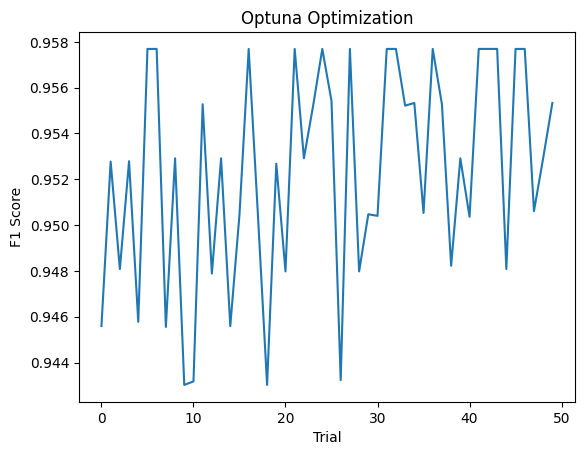

In [213]:
#!pip install optuna

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ╔══════════════════════════════════════════════════════════════╗
# ║  БОНУС: Реализуйте objective-функцию для Optuna              ║
# ║  Используйте те же параметры, что в Random Search            ║
# ║  Запустите study.optimize с n_trials=50                      ║
# ║                                                              ║
# ║  Постройте график сходимости:                                ║
# ║  plt.plot(range(n_trials), best_values_over_time)            ║
# ║  Сравните кривые Optuna и Random Search (если логировали)    ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 10, 200)
    max_depth = trial.suggest_int('max_depth', 2, 32, log=True)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    
    clf = RandomForestClassifier(
        n_estimators=n_estimators, 
        max_depth=max_depth, 
        min_samples_split=min_samples_split,
        random_state=42
    )
    
    score = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1_macro').mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)
print(f"Лучший результат Optuna: {study.best_value:.4f}")
print(f"Лучшие параметры: {study.best_params}")

plt.plot(study.trials_dataframe()['value'])
plt.title('Optuna Optimization')
plt.xlabel('Trial')
plt.ylabel('F1 Score')
plt.show() 